In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("placement (1).csv")

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.shape

(1000, 3)

C:\Users\swaya\AppData\Local\Temp\ipykernel_14100\3634761583.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\swaya\AppData\Local\Temp\ipykernel_14100\3634761583.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


<Figure size 640x480 with 0 Axes>

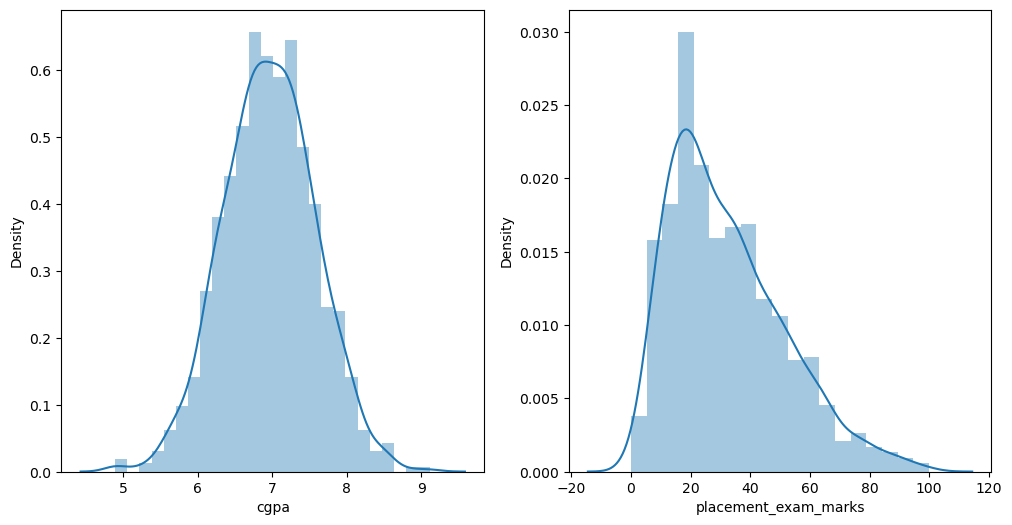

In [5]:
fig = plt.figure()
plt.figure(figsize=(12,6))
plt.subplot(1 , 2, 1)
sns.distplot(df['cgpa'])

plt.subplot(1 , 2, 2)
sns.distplot(df['placement_exam_marks']) 
plt.show()

### we can see that cgpa is normally distributed while placement_exam_marks is left skewed

In [6]:
#printing boundary values
highest = (df['cgpa'].mean() + 3*df['cgpa'].std())
lowest = (df['cgpa'].mean() - 3*df['cgpa'].std())

In [7]:
print("highest" , highest)
print("lowest" , lowest)


highest 8.808933625397168
lowest 5.113546374602832


# trimming

#### approach 1

In [8]:
new_df = df[(df['cgpa'] < highest) & (df['cgpa'] > lowest)]

In [9]:
new_df.shape

(995, 3)

##### approach 2

In [10]:
#z-score
df['z-score-col'] = ((df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std())

In [11]:
df.sample(10)

,cgpa,placement_exam_marks,placed,z-score-col
471,5.48,18.0,0,-2.405009
862,6.04,37.0,1,-1.495767
76,8.35,12.0,0,2.254854
842,7.33,14.0,1,0.598736
390,6.63,16.0,1,-0.537816
980,6.18,27.0,0,-1.268457
552,6.40,24.0,0,-0.911255
36,6.85,16.0,1,-0.180614
904,7.36,32.0,0,0.647445
482,7.56,8.0,0,0.972174


In [12]:
df[(df['z-score-col'] > 3) | (df['z-score-col'] < -3)]

,cgpa,placement_exam_marks,placed,z-score-col
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [13]:
df.shape

(1000, 4)

In [14]:
new_df1 = df[(df['z-score-col'] < 3) & (df['z-score-col'] > -3)]

In [15]:
new_df1

,cgpa,placement_exam_marks,placed,z-score-col
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


# Capping

In [16]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()


In [17]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [18]:
df.shape


(1000, 4)

In [19]:
df['cgpa'].describe()


count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

In [20]:
df.head()

,cgpa,placement_exam_marks,placed,z-score-col
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
